# Social Media Impact on Students' Life

### Data Analysis Portfolio Project

This notebook explores how social media usage patterns relate to sleep, stress, mental health, and academic performance among students, using a dataset of 4,500 student records.

**Goals:**
- Clean and prepare the raw dataset
- Explore key relationships (usage vs mental health, usage vs GPA, etc.)
- Visualize findings
- Summarize actionable insights


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('Social_media_impact_on_life.csv')
df.head()

    Student_ID  Age  ... Academic_Performance_GPA Overall_Impact
0  STU_2024000   19  ...                     2.73        Neutral
1  STU_2024001   19  ...                     3.21     Beneficial
2  STU_2024002   17  ...                     3.00        Neutral
3  STU_2024003   16  ...                     3.42     Beneficial
4  STU_2024004   17  ...                     3.41     Beneficial

[5 rows x 16 columns]

In [2]:
df.shape

(4500, 16)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   str    
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   str    
 3   Academic_Level               4500 non-null   str    
 4   Primary_Platform             4500 non-null   str    
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   str    
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   str    
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Index          

## 2. Data Cleaning

Check for missing values, duplicates, and fix data types.

In [4]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [5]:
# Fill numeric missing values with median (robust to outliers)
df['Perceived_Stress_Score'] = df['Perceived_Stress_Score'].fillna(df['Perceived_Stress_Score'].median())
df['Academic_Performance_GPA'] = df['Academic_Performance_GPA'].fillna(df['Academic_Performance_GPA'].median())

# Convert boolean column to int for correlation analysis
df['Late_Night_Usage'] = df['Late_Night_Usage'].astype(int)

print('Duplicate rows:', df.duplicated().sum())
print('Remaining missing values:', df.isnull().sum().sum())

Duplicate rows: 0
Remaining missing values: 0


## 3. Exploratory Data Analysis (EDA)

In [6]:
num_cols = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Sleep_Duration_Hours',
            'Sleep_Quality_Score', 'Late_Night_Usage', 'Perceived_Stress_Score',
            'Mental_Health_Index', 'Academic_Performance_GPA']

df[num_cols].describe()

               Age  ...  Academic_Performance_GPA
count  4500.000000  ...               4500.000000
mean     18.703333  ...                  3.429862
std       1.981182  ...                  0.388957
min      15.000000  ...                  1.900000
25%      17.000000  ...                  3.200000
50%      19.000000  ...                  3.460000
75%      20.000000  ...                  3.720000
max      26.000000  ...                  4.000000

[8 rows x 9 columns]

### 3.1 Overall Impact Distribution

How are students distributed across Beneficial / Neutral / Negative impact categories?

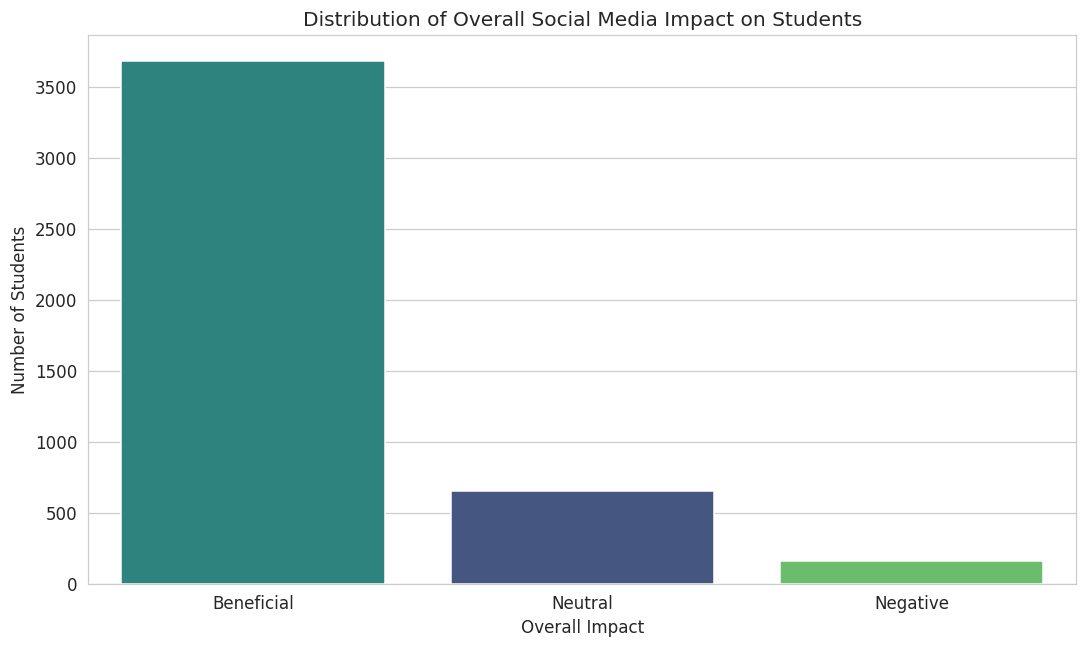

In [7]:
plt.figure()
order = df['Overall_Impact'].value_counts().index
sns.countplot(data=df, x='Overall_Impact', order=order, hue='Overall_Impact', palette='viridis', legend=False)
plt.title('Distribution of Overall Social Media Impact on Students')
plt.xlabel('Overall Impact')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

### 3.2 Average Daily Usage by Platform

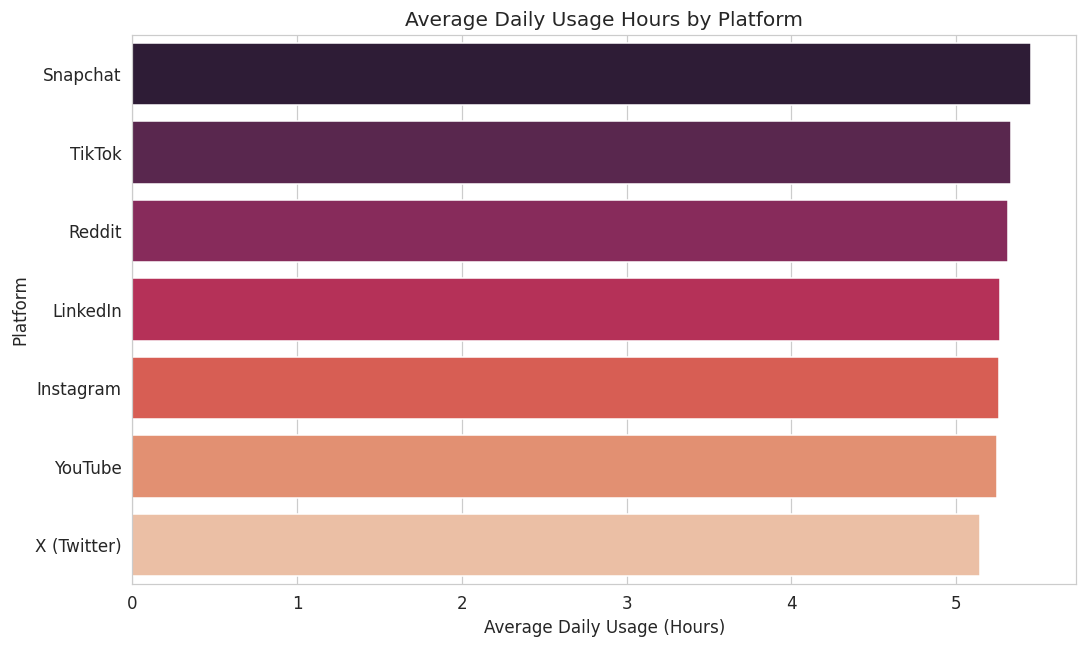

In [8]:
platform_usage = df.groupby('Primary_Platform')['Daily_Usage_Hours'].mean().sort_values(ascending=False)

plt.figure()
sns.barplot(x=platform_usage.values, y=platform_usage.index, hue=platform_usage.index, palette='rocket', legend=False)
plt.title('Average Daily Usage Hours by Platform')
plt.xlabel('Average Daily Usage (Hours)')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

Which numeric variables move together most strongly?

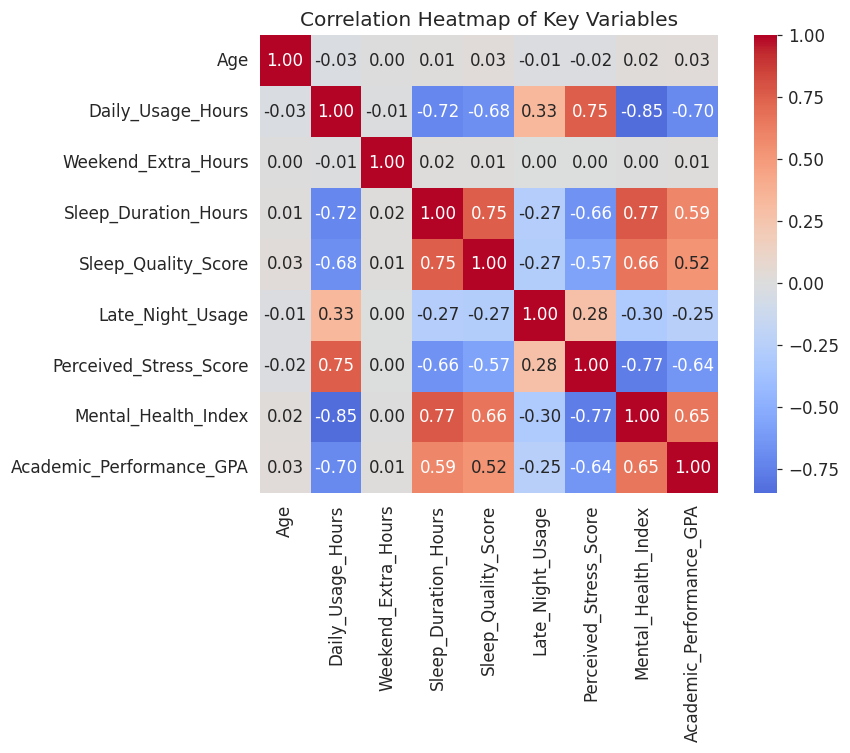

In [9]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.show()

### 3.4 Daily Usage vs Mental Health Index

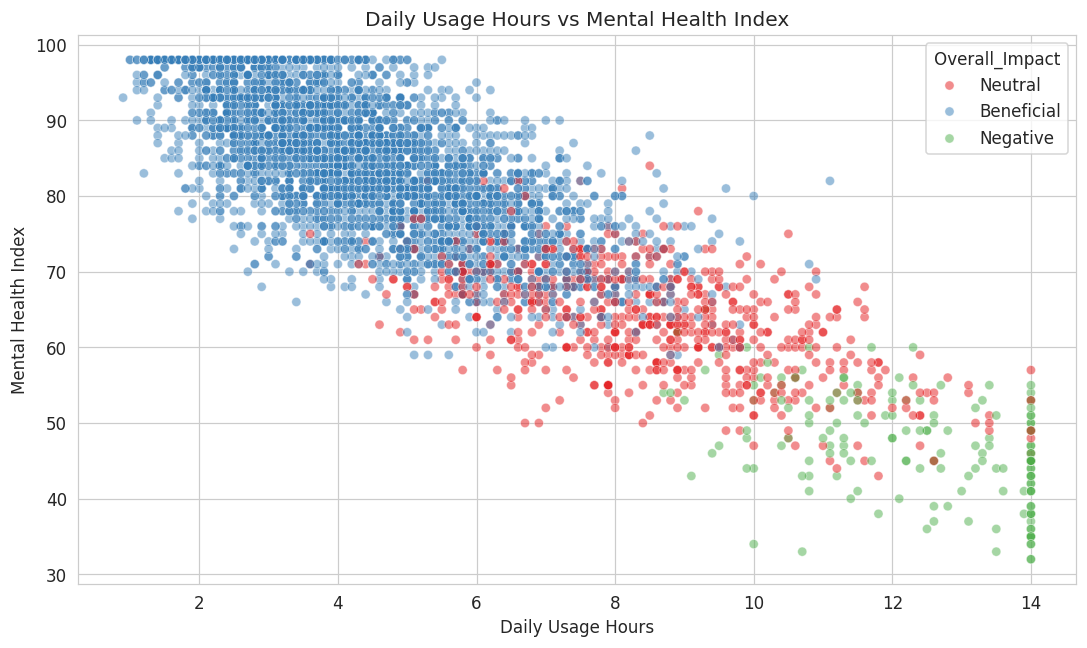

In [10]:
plt.figure()
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Mental_Health_Index',
                hue='Overall_Impact', alpha=0.5, palette='Set1')
plt.title('Daily Usage Hours vs Mental Health Index')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Mental Health Index')
plt.tight_layout()
plt.show()

### 3.5 Sleep Duration vs Academic GPA

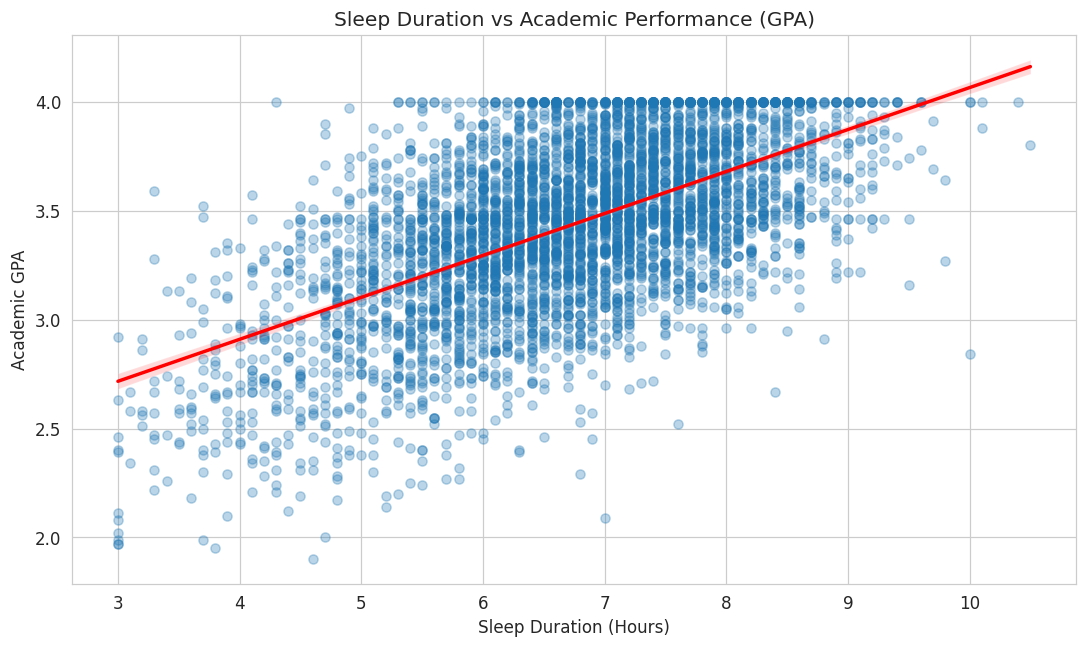

In [11]:
plt.figure()
sns.regplot(data=df, x='Sleep_Duration_Hours', y='Academic_Performance_GPA',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Sleep Duration vs Academic Performance (GPA)')
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Academic GPA')
plt.tight_layout()
plt.show()

### 3.6 Social Comparison Frequency vs Perceived Stress

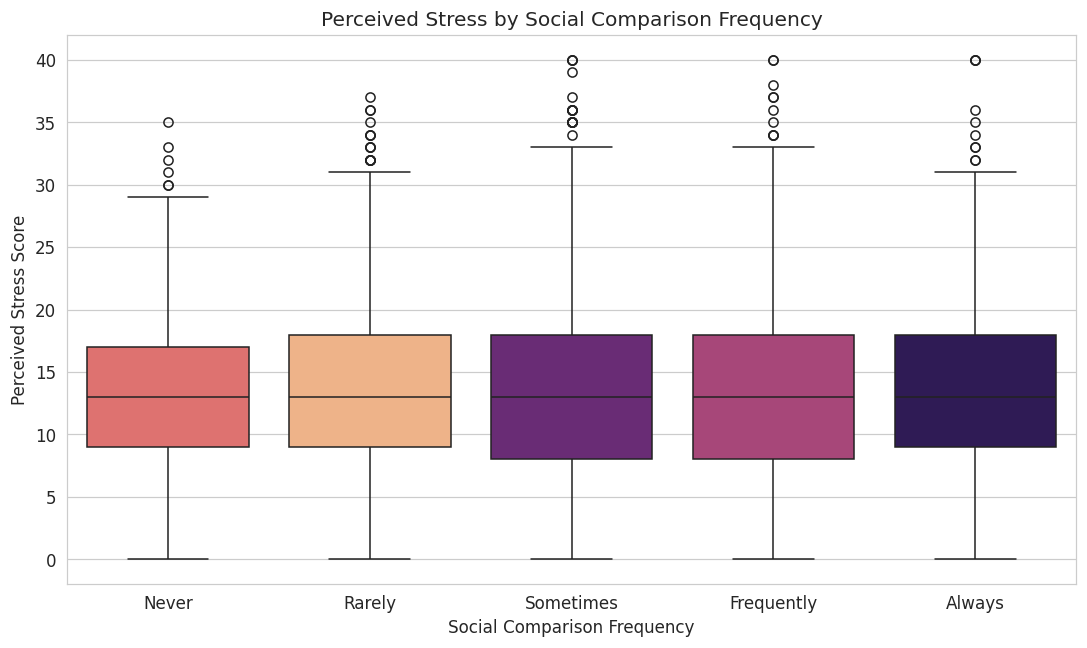

In [12]:
plt.figure()
comp_order = ['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always']
sns.boxplot(data=df, x='Social_Comparison_Frequency', y='Perceived_Stress_Score',
            order=comp_order, hue='Social_Comparison_Frequency', palette='magma', legend=False)
plt.title('Perceived Stress by Social Comparison Frequency')
plt.xlabel('Social Comparison Frequency')
plt.ylabel('Perceived Stress Score')
plt.tight_layout()
plt.show()

### 3.7 Late Night Usage vs Sleep Quality

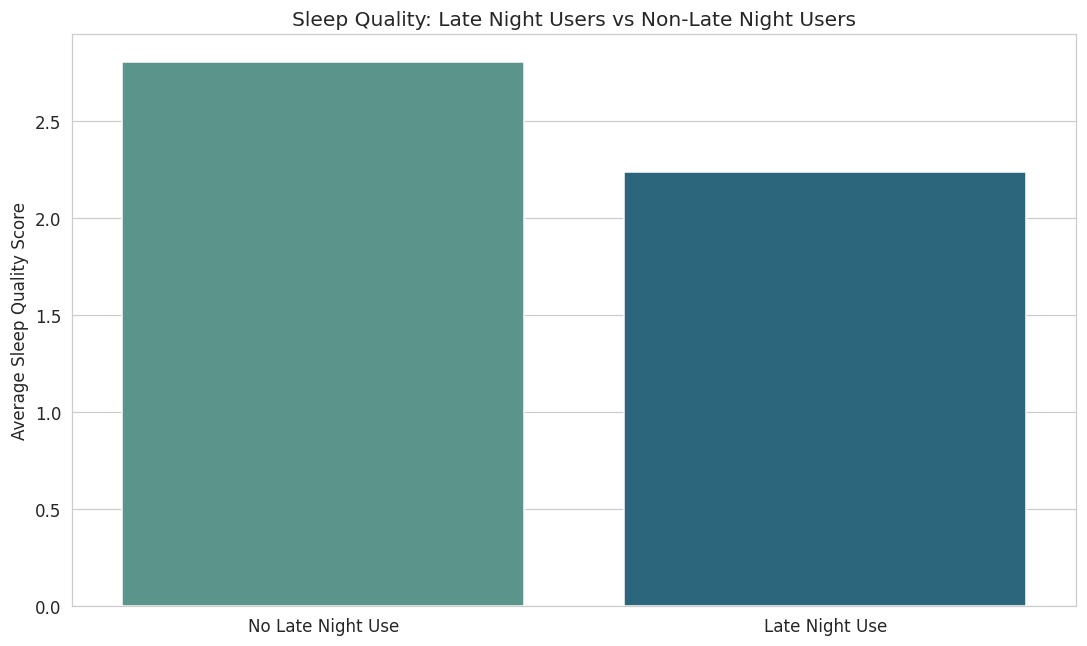

In [13]:
late_night_impact = df.groupby('Late_Night_Usage')['Sleep_Quality_Score'].mean()

plt.figure()
sns.barplot(x=['No Late Night Use', 'Late Night Use'], y=late_night_impact.values,
            hue=['No Late Night Use', 'Late Night Use'], palette='crest', legend=False)
plt.title('Sleep Quality: Late Night Users vs Non-Late Night Users')
plt.ylabel('Average Sleep Quality Score')
plt.tight_layout()
plt.show()

## 4. Key Insights

1. **Usage vs Mental Health:** Daily usage hours has a strong negative correlation with Mental Health Index (r ≈ -0.85) — heavier social media use tracks with worse self-reported mental health.

2. **Usage vs Academic Performance:** Daily usage also correlates negatively with GPA (r ≈ -0.71).

3. **Impact Categories:** Students labeled "Negative" impact use social media ~12.3 hrs/day on average, vs only ~4.4 hrs/day for students labeled "Beneficial".

4. **Sleep as a Mediator:** Sleep Duration correlates strongly with Mental Health Index (r ≈ 0.77), suggesting sleep may be a key pathway through which social media affects wellbeing.

5. **Social Comparison:** Students who "Always" compare themselves to others on social media report visibly higher stress scores than those who "Never" do.

6. **Platform Differences:** Snapchat and TikTok users report the highest average daily usage (~5.3–5.5 hrs), while X (Twitter) and LinkedIn users report the lowest.

7. **Late Night Usage:** Students who use social media late at night report lower average sleep quality scores.

## 5. Conclusion

The data suggests a clear pattern: **higher, especially late-night, social media usage is associated with poorer sleep, higher stress, and lower mental health and academic outcomes.** Sleep duration appears to be an important mediating factor. These findings could inform student wellness programs focused on usage moderation and sleep hygiene, rather than blanket social media bans.

*Note: These are correlational findings, not causal proof — other confounding factors (personality, environment, workload) may also play a role.*
